In [1]:
import numpy as np
import pickle


from typing import TypedDict

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import CXGate, PauliEvolutionGate, QAOAAnsatz

from qiskit_aer import AerSimulator
from qiskit_aer.backends.backendconfiguration import AerBackendConfiguration

from qiskit.transpiler import PassManager, Layout
from qiskit.transpiler.passes import InverseCancellation, CommutativeCancellation
from qopt_best_practices.transpilation.swap_cancellation_pass import SwapToFinalMapping

from hubo_qaoa.utils.get_swap_strategy import get_swap_strategy
from hubo_qaoa.utils.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph

from qiskit_qaoa.utils.transpiler_passes import ExtendedSwapStrategy, FindCommutingPauliEvolutionsMulti
from qiskit_qaoa.utils.commuting_gate_router_precompute_rzz import CommutingGateRouterPrecomputeRzz
from qiskit_qaoa.utils.commuting_gate_router_rzz import CommutingGateRouterRzz

from qiskit_qaoa.utils.sat_mapper import HigherOrderSatMapper
from qiskit_qaoa.utils.hamiltonian_utils import hamiltonian_to_interactions


In [2]:
filename = 'test_N4_W5'
copy_numbers = [2,1,1,1]
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'

In [3]:
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
hamiltonian = hamiltonian * norm
num_virtual_qubits: int = hamiltonian.num_qubits

extended_swap_strat = get_swap_strategy('heavy-hex', n, T)

    
num_physical_qubits = extended_swap_strat._num_vertices
donor_qc = QuantumCircuit(num_physical_qubits)

program_interactions = hamiltonian_to_interactions(hamiltonian, 0, 1.0)

Keeping constraints at times: [1 2 0 3]
Min size to support virtual qubits: (1, 2)


In [4]:
layer=0

In [5]:
pm_rzz = PassManager(
    [
        FindCommutingPauliEvolutionsMulti(), 
        CommutingGateRouterRzz(
            extended_swap_strat,
            max_layers=0,
            perform_extra_swaps=True
        ),
        SwapToFinalMapping(),
        InverseCancellation(gates_to_cancel=[CXGate()]),
        CommutativeCancellation(basis_gates=["cx", "swap", "rz", "rzz"]),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)

In [6]:
mapper = HigherOrderSatMapper(timeout=60)


In [7]:
# sat_results = mapper.hubo_max_sat(
#     num_physical_qubits, program_interactions, extended_swap_strat, layer
# )

In [8]:
# mapping = sat_results[layer][1]
# edge_map = dict(mapping)
# donor_qc = QuantumCircuit(num_physical_qubits)
# layout = Layout({donor_qc.qubits[key]: val for key, val in edge_map.items()})

In [9]:
layout = Layout({
6: donor_qc.qubits[0],
5: donor_qc.qubits[1],
11: donor_qc.qubits[2],
0: donor_qc.qubits[3],
10: donor_qc.qubits[4],
17: donor_qc.qubits[5],
12: donor_qc.qubits[6],
1: donor_qc.qubits[7],
13: donor_qc.qubits[8],
2: donor_qc.qubits[9],
14: donor_qc.qubits[10],
7: donor_qc.qubits[11],
18: donor_qc.qubits[12],
19: donor_qc.qubits[13],
8: donor_qc.qubits[14],
15: donor_qc.qubits[15],
20: donor_qc.qubits[16],
3: donor_qc.qubits[17],
4: donor_qc.qubits[18],
16: donor_qc.qubits[19],
9: donor_qc.qubits[20]
})
layout

Layout({
6: <Qubit register=(21, "q"), index=0>,
5: <Qubit register=(21, "q"), index=1>,
11: <Qubit register=(21, "q"), index=2>,
0: <Qubit register=(21, "q"), index=3>,
10: <Qubit register=(21, "q"), index=4>,
17: <Qubit register=(21, "q"), index=5>,
12: <Qubit register=(21, "q"), index=6>,
1: <Qubit register=(21, "q"), index=7>,
13: <Qubit register=(21, "q"), index=8>,
2: <Qubit register=(21, "q"), index=9>,
14: <Qubit register=(21, "q"), index=10>,
7: <Qubit register=(21, "q"), index=11>,
18: <Qubit register=(21, "q"), index=12>,
19: <Qubit register=(21, "q"), index=13>,
8: <Qubit register=(21, "q"), index=14>,
15: <Qubit register=(21, "q"), index=15>,
20: <Qubit register=(21, "q"), index=16>,
3: <Qubit register=(21, "q"), index=17>,
4: <Qubit register=(21, "q"), index=18>,
16: <Qubit register=(21, "q"), index=19>,
9: <Qubit register=(21, "q"), index=20>
})

In [10]:
qc = QuantumCircuit(num_physical_qubits)
qc.append(PauliEvolutionGate(hamiltonian), [layout.get_virtual_bits()[donor_qc.qubits[i]] for i in range(num_virtual_qubits)])     
    
tqc_rzz = pm_rzz.run(qc)

Max layers needed to apply swap decompose: 0
Gates we cannot directly implement: 139
[(2, 8, 14, 18), (1, 14), (8, 14), (0, 10, 11, 17), (1, 12, 13, 14), (0, 1, 10, 13, 17), (1, 5), (1, 7, 12, 14), (7, 13, 14), (1, 7, 12), (6, 12), (10, 13), (0, 10, 13), (2, 7, 12, 13), (1, 13, 14), (0, 18), (0, 5, 10, 17), (6, 10, 11, 17), (0, 6, 10, 11), (0, 6, 10, 11, 17), (1, 2, 7, 13), (1, 12, 13, 17), (7, 8, 18), (10, 13, 17), (0, 10, 18, 19), (0, 5, 6, 10, 17), (0, 5, 6, 10), (0, 1, 10, 17), (8, 14, 19), (1, 12, 17), (0, 5, 6), (1, 10, 13), (5, 6, 10, 11), (1, 2, 7, 12), (0, 5, 6, 11), (10, 11, 17), (2, 8), (5, 10, 11), (7, 12, 14), (2, 7, 8, 14, 18), (12, 17), (0, 10, 13, 17), (0, 11, 17), (2, 8, 19), (14, 18, 19), (5, 14), (2, 8, 18, 19), (5, 10), (1, 2, 7, 14), (0, 6, 11, 17), (0, 10, 12, 17), (7, 12, 13), (1, 2, 7, 13, 14), (10, 11), (0, 10, 12, 13, 17), (1, 10, 12, 13), (1, 7, 13, 14), (6, 11, 17), (1, 10, 12, 17), (0, 1, 13), (1, 19), (5, 19), (2, 7, 8, 19), (1, 12, 14), (0, 2), (2, 7, 8, 

In [11]:
from qiskit import generate_preset_pass_manager
cm = extended_swap_strat._coupling_map
pm = generate_preset_pass_manager(
    optimization_level=3, 
    coupling_map=cm, 
    basis_gates=['rz', 'rzz','cx', 'id', 'swap'],
    initial_layout=layout
)
pm.layout=None
pm.init.remove(6)

In [12]:
pm.stages


('init', 'layout', 'routing', 'translation', 'optimization', 'scheduling')

In [13]:
init_qc = pm.init.run(qc)
print(init_qc.count_ops())
routed_qc = pm.routing.run(init_qc)
print(routed_qc.count_ops())
translated_qc = pm.translation.run(routed_qc)
print(translated_qc.count_ops())
optimized_qc = pm.optimization.run(translated_qc)
print(optimized_qc.count_ops())



OrderedDict([('cx', 440), ('rz', 156), ('rzz', 45)])
OrderedDict([('cx', 440), ('swap', 275), ('rz', 156), ('rzz', 45)])
OrderedDict([('cx', 440), ('swap', 275), ('rz', 156), ('rzz', 45)])
OrderedDict([('cx', 392), ('swap', 275), ('rz', 156), ('rzz', 45)])


In [14]:
pm.init[0:8].run(qc).count_ops()

OrderedDict([('cx', 440), ('rz', 156), ('rzz', 45)])

In [15]:
import re

def matcher(input):
    return tuple([int(re.findall(r'index=([0-9]+)', str(x))[0]) for x in input])

seen = set()
for gate in tqc_rzz:
    if gate.operation.num_qubits == 2:
        # print(gate.qubits)
        # print(matcher(gate.qubits))
        if matcher(gate.qubits) not in list(extended_swap_strat._coupling_map):
            seen.add(matcher(gate.qubits))
            # print(matcher(gate.qubits), gate.operation.name)
print(seen)

set()


In [3]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingheavy-hex.precompute.60.pkl'
with open(data_file, 'rb') as f:
    res_hardware = pickle.load(f)
    
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)



In [17]:
filename = 'test_N2_W2'
filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
copy_numbers = [1,1]

cost_circuit = res_hardware[filename]['rzz']['circuit']
cost_circuit.draw(fold=-1)

global phase: 2.8164
                               ┌───┐                               ┌───┐                                         
  q_3 -> 3 ─■─────────■────────┤ X ├─────────────────■─────────────┤ X ├─X─────■──────────X─────────────■────────
            │         │        └─┬─┘                 │             └─┬─┘ │     │          │             │        
  q_4 -> 4 ─┼─────────┼──────────┼───■───────────■───┼──────────■────┼───┼──X──┼──────────┼──■──────────┼────────
            │ZZ(4.5)  │          │   │           │   │          │    │   │  │  │          │  │          │ZZ(2.5) 
  q_7 -> 7 ─■─────────┼──────────■───┼───────────┼───┼──────────┼────■───X──┼──┼──────────┼──┼──────────■────────
                      │ZZ(2.5)       │ZZ(-2.5) ┌─┴─┐ │ZZ(2.5) ┌─┴─┐         │  │ZZ(-2.5)  │  │ZZ(-2.5)           
q_10 -> 10 ───────────■──────────────■─────────┤ X ├─■────────┤ X ├─────────X──■──────────X──■───────────────────
                                               └───┘          └───┘

In [18]:
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
hamiltonian = hamiltonian * norm
num_virtual_qubits: int = hamiltonian.num_qubits

extended_swap_strat = get_swap_strategy('heavy-hex', n, T)

    
num_physical_qubits = extended_swap_strat._num_vertices
donor_qc = QuantumCircuit(num_physical_qubits)

program_interactions = hamiltonian_to_interactions(hamiltonian, 0, 1.0)

Keeping constraints at times: [0]
Min size to support virtual qubits: (1, 1)


In [22]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(name='us_instance')
backend = service.backend(name='ibm_boston')

In [23]:
backend.coupling_map

12


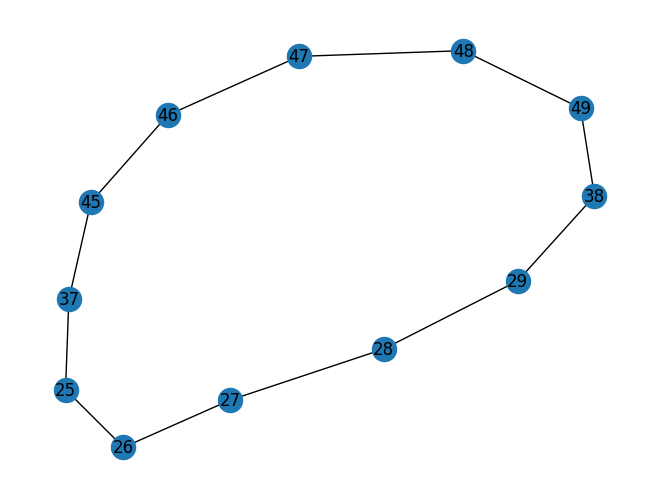

In [24]:
import networkx as nx
g = nx.Graph()
# ranges = list(range(21, 30))+list(range(36,50))
# ranges.remove(40)
ranges = list(range(25, 30))+list(range(37,39)) +list(range(45,50))
filtered_edges = [x for x in list(backend.coupling_map) if x[0] in ranges and x[1] in ranges]
g.add_edges_from(filtered_edges)
print(len(g.nodes))
nx.draw(g,with_labels=True)

12


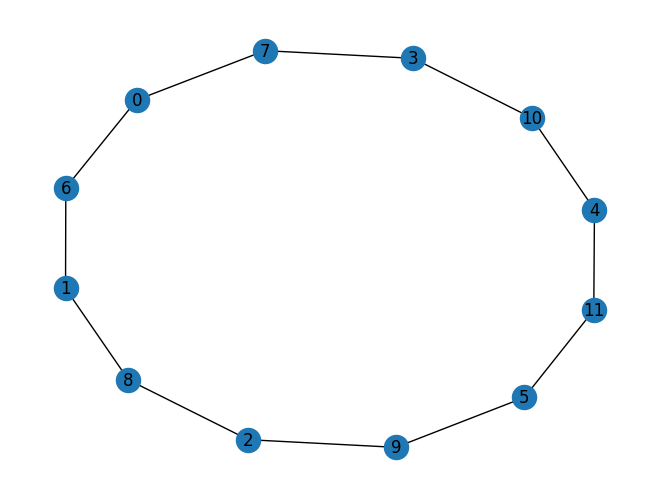

In [25]:
extended_swap_strat = ExtendedSwapStrategy.from_heavy_hex(1, 1)
gg = nx.Graph()
filtered_edges = [x for x in list(extended_swap_strat._coupling_map)]
gg.add_edges_from(filtered_edges)
print(len(gg.nodes))
nx.draw(gg,with_labels=True)

In [26]:
gm = nx.algorithms.isomorphism.vf2pp_isomorphism(gg, g)
qc = QuantumCircuit(backend.num_qubits, cost_circuit.num_clbits)
qubits_map = [qc.qubits[gm[i]] for i in range(cost_circuit.num_qubits)]
qubits_map

[<Qubit register=(156, "q"), index=37>,
 <Qubit register=(156, "q"), index=26>,
 <Qubit register=(156, "q"), index=28>,
 <Qubit register=(156, "q"), index=46>,
 <Qubit register=(156, "q"), index=48>,
 <Qubit register=(156, "q"), index=38>,
 <Qubit register=(156, "q"), index=25>,
 <Qubit register=(156, "q"), index=45>,
 <Qubit register=(156, "q"), index=27>,
 <Qubit register=(156, "q"), index=29>,
 <Qubit register=(156, "q"), index=47>,
 <Qubit register=(156, "q"), index=49>]

In [4]:
from hubo_qaoa.utils.lr_qaoa import get_hardware_LR_qaoa_circuit, get_LR_qaoa_circuit
from qiskit.circuit import ParameterVector

delta_b, delta_g = 0.75, 0.30
p = 1
num_qubits: int = n*T
phis = ParameterVector('ϕ', num_qubits)
fixed_qc, backend_circ, layout_circ, qaoa_circ = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, res_hardware[filename]['rzz']['layout'], backend, None, phis)


abstract_cost_circuit = res[filename]['rzz']['circuit']
abstract_qc, _ = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, abstract_cost_circuit, None, phis, True) 

NameError: name 'n' is not defined

In [28]:
backend_circ.count_ops(),layout_circ.count_ops()

(OrderedDict([('rz', 73), ('sx', 67), ('cz', 28), ('measure', 4)]),
 OrderedDict([('ry', 12),
              ('rzz', 7),
              ('cx', 4),
              ('rz', 4),
              ('measure', 4),
              ('swap', 3)]))

In [ ]:
generic_pm = generate_preset_pass_manager(
    optimization_level=3, 
    backend=backend,
    initial_layout=layout
) # , scheduling_method="alap"
generic_pm.layout = None
backend_circ = generic_pm.run(layout_circ)

In [ ]:
generic_pm = generate_preset_pass_manager(optimization_level=3, backend=backend, scheduling_method="alap")
backend_circ = generic_pm.run(qaoa_circuit)